In [1]:
#Project: Kelly Criterion Portfolio
#Author: Ryan Kelly
#Data: Hourly prices (last 1 year) for selected US stocks
#Goal: Estimate Kelly weights and evaluate portfolio performance

In [17]:
#Core Libraries
import yfinance as yf
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.optimize as optimal
from matplotlib.pyplot import figure
from prettytable import PrettyTable
from tabulate import tabulate
from numpy.lib.stride_tricks import sliding_window_view
import copy
import warnings
warnings.filterwarnings("ignore")

In [18]:
#Portfolio
portfolio = ['AAPL','MSFT','NVDA','GOOGL','META','NEE','FSLR','SPWR',
             'JPM','BAC','WFC','ABBV','PFE','UNH','GE','HON','CAT',
             'PG','KO','WMT']
#Risk Free
rf_year = 2.90/100
rf_hour = 3.26*(10**(-6))   #given by instructor

In [29]:
from datetime import datetime

start_date = datetime(2024, 12, 1)
end_date   = datetime(2025, 12, 1)

start_str = start_date.strftime("%Y-%m-%d")
end_str   = end_date.strftime("%Y-%m-%d")

print("StartDate:", start_str)
print("EndDate:", end_str)

StartDate: 2024-12-01
EndDate: 2025-12-01


In [30]:
#Download Hourly Prices
prices = pd.DataFrame()

for asset in portfolio:
    ticker = yf.Ticker(asset)
    hist = ticker.history(start=start_str, end=end_str, interval="60m")
    if hist.empty:
        print(f"Warning: no data returned for {asset}")
        continue
    prices[asset] = hist['Close']

In [31]:
#Drop Rows With Missing Values
prices = prices.dropna()

print("PriceDataShape:", prices.shape)
display(prices.head())

PriceDataShape: (1042, 20)


,AAPL,MSFT,NVDA,GOOGL,META,NEE,FSLR,SPWR,JPM,BAC,WFC,ABBV,PFE,UNH,GE,HON,CAT,PG,KO,WMT
Datetime,,,,,,,,,,,,,,,,,,,,
2025-04-28 09:30:00-04:00,208.929993,389.445007,108.525200,160.174103,548.080017,65.580002,141.365005,1.988,244.410004,39.915001,69.849998,188.850006,23.180000,419.165009,200.929993,189.095200,310.529999,161.115005,71.580002,95.724998
2025-04-28 10:30:00-04:00,207.949997,388.170013,106.599998,159.589996,540.690002,66.180000,140.089996,2.000,241.880005,39.639999,69.250000,189.259995,23.090000,417.200012,198.865005,188.491989,306.959991,162.509995,71.955002,95.139999
2025-04-28 11:30:00-04:00,207.860001,386.989990,106.550903,158.940002,543.138977,65.910797,139.479996,1.985,241.214996,39.549999,69.029999,190.880005,23.014999,416.609985,199.080002,187.573044,304.410004,161.399994,71.714996,94.989998
2025-04-28 12:30:00-04:00,208.139999,387.140015,106.279999,158.830002,544.325012,65.639999,138.904999,1.985,241.020004,39.483700,68.870003,190.875000,22.940001,416.620911,198.949997,186.691803,304.535004,161.000000,71.375000,94.415001
2025-04-28 13:30:00-04:00,209.869995,390.929993,107.300003,159.350006,546.799988,65.989998,139.755005,2.000,241.720001,39.630001,69.110001,191.725006,23.014999,417.649994,200.199997,188.303482,306.049988,161.425003,71.665001,94.900002


In [32]:
#Hourly Returns
R_df = prices.pct_change().dropna()

In [33]:
#Excess Returns
ExcessReturn_df = R_df - rf_hour

print("ExcessReturnShape:", ExcessReturn_df.shape)
display(ExcessReturn_df.head())

ExcessReturnShape: (1041, 20)


,AAPL,MSFT,NVDA,GOOGL,META,NEE,FSLR,SPWR,JPM,BAC,WFC,ABBV,PFE,UNH,GE,HON,CAT,PG,KO,WMT
Datetime,,,,,,,,,,,,,,,,,,,,
2025-04-28 10:30:00-04:00,-0.004694,-0.003277,-0.017743,-0.003650,-0.013487,0.009146,-0.009023,0.006033,-0.010355,-0.006893,-0.008593,0.002168,-0.003886,-0.004691,-0.010280,-0.003193,-0.011500,0.008655,0.005236,-0.006115
2025-04-28 11:30:00-04:00,-0.000436,-0.003043,-0.000464,-0.004076,0.004526,-0.004071,-0.004358,-0.007503,-0.002753,-0.002274,-0.003180,0.008556,-0.003251,-0.001418,0.001078,-0.004879,-0.008310,-0.006834,-0.003339,-0.001580
2025-04-28 12:30:00-04:00,0.001344,0.000384,-0.002546,-0.000695,0.002180,-0.004112,-0.004126,-0.000003,-0.000812,-0.001680,-0.002321,-0.000029,-0.003262,0.000023,-0.000656,-0.004701,0.000407,-0.002482,-0.004744,-0.006056
2025-04-28 13:30:00-04:00,0.008308,0.009786,0.009594,0.003271,0.004544,0.005329,0.006116,0.007553,0.002901,0.003702,0.003482,0.004450,0.003266,0.002467,0.006280,0.008630,0.004971,0.002637,0.004060,0.005134
2025-04-28 14:30:00-04:00,0.003189,0.001378,0.008291,0.004546,0.005646,0.000982,-0.000182,0.014997,0.004217,0.004791,0.003180,0.002944,-0.001307,0.006904,0.001795,0.001959,0.002709,0.003125,-0.000213,0.000945


In [34]:
#Convert to numpy for ACE
R = ExcessReturn_df.to_numpy()
T, N = R.shape
print("T:", T, "N:", N)

T: 1041 N: 20


In [39]:
#KellyWindowHelperwith21percentcap
def kelly_one_window(R_window, cap=0.21):
    mu = R_window.mean(axis=0)
    cov = np.cov(R_window, rowvar=False)

    try:
        inv_cov = np.linalg.inv(cov)
    except np.linalg.LinAlgError:
        return np.ones(mu.shape[0]) / mu.shape[0]

    raw = inv_cov @ mu

    #Long-only
    raw[raw < 0] = 0
    if raw.sum() == 0:
        return np.ones_like(raw) / len(raw)

    #Normalize
    w = raw / raw.sum()

    #Apply per-asset cap (iterative redistribution)
    w = w.copy()
    for _ in range(10 * len(w)):  #safetylimit
        over = w > cap + 1e-12
        if not np.any(over):
            break

        #totalweightabovecap
        excess = np.sum(w[over] - cap)
        w[over] = cap

        under = w < cap - 1e-12
        if not np.any(under):
            break

        #redistributeexcesstopositionsunder the cap, proportional
        w[under] += excess * (w[under] / np.sum(w[under]))

    #finalrenormalizationfornumericalstability
    return w / w.sum()

In [40]:
#Simple Additional Method: Equal Weight
def equal_weight_window(N_local):
    return np.ones(N_local)/N_local

#ACE Weight Function
def getweight(N, T, M, R, method, r=0.002, gamma=5, delta=0.01):
    """
    N: number of assets
    T: number of time periods
    M: window length
    R: np.array shape (T, N) of excess returns
    method: 'kelly' or 'ew' for now
    """
    kappa = 0.0125
    weight = np.full(shape=(T, N), fill_value=np.nan)

    #Sliding Window
    data = sliding_window_view(R, (M, N))
    #datashape:(T-M+1, 1, M, N)

    #Kelly Criterion
    if method == 'kelly':
        for i in range(data.shape[0]-1):
            R_window = data[i][0]
            w_kelly = kelly_one_window(R_window)
            weight[i+M] = w_kelly

    #Equal Weight as New Method
    if method == 'ew':
        for i in range(data.shape[0]-1):
            w_ew = equal_weight_window(N)
            weight[i+M] = w_ew

    return weight

KellyWeightsShape: (1041, 20)
EqualWeightShape: (1041, 20)


,Stock,KellyWeight
0,AAPL,0.000000
1,MSFT,0.000000
2,NVDA,0.006043
3,GOOGL,0.038273
4,META,0.210000
5,NEE,0.033573
6,FSLR,0.043319
7,SPWR,0.000000
8,JPM,0.101140
9,BAC,0.008044


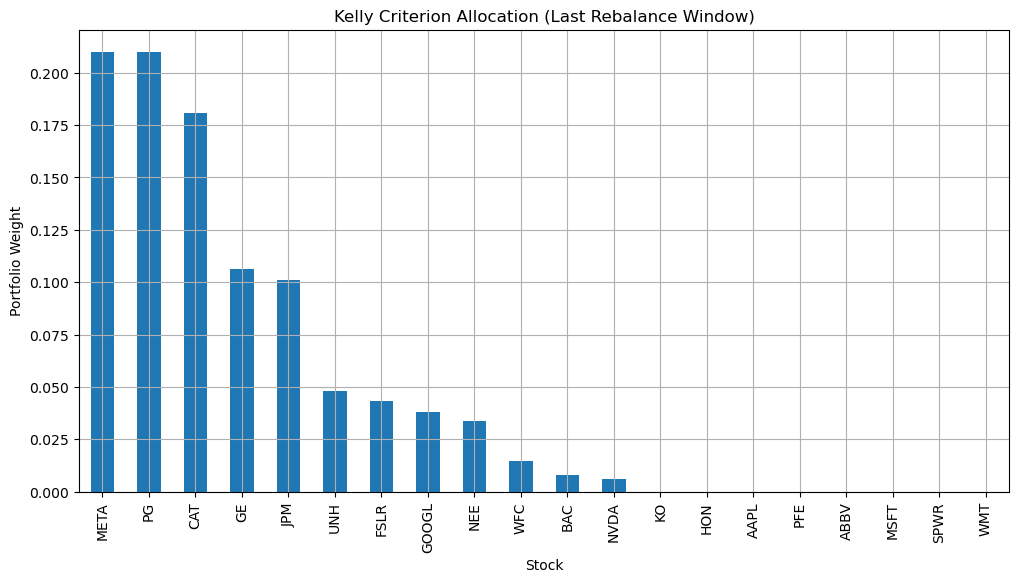

In [41]:
#Window Length(for example: 24 hours)
M = 24

#Compute Weights
weight_kelly = getweight(N, T, M, R, method='kelly')
weight_ew = getweight(N, T, M, R, method='ew')

print("KellyWeightsShape:", weight_kelly.shape)
print("EqualWeightShape:", weight_ew.shape)

#Last Valid Kelly Weights
valid_idx = np.where(~np.isnan(weight_kelly[:,0]))[0]
last_idx = valid_idx[-1]
last_kelly = weight_kelly[last_idx]

kelly_series_last = pd.Series(last_kelly, index=prices.columns, name="KellyWeight_LastRebalance")
kelly_table = kelly_series_last.reset_index()
kelly_table.columns = ["Stock","KellyWeight"]
display(kelly_table)

#Plot Last Kelly Allocation
plt.figure(figsize=(12,6))
kelly_series_last.sort_values(ascending=False).plot(kind="bar")
plt.title("Kelly Criterion Allocation (Last Rebalance Window)")
plt.ylabel("Portfolio Weight")
plt.xlabel("Stock")
plt.grid()
plt.show()

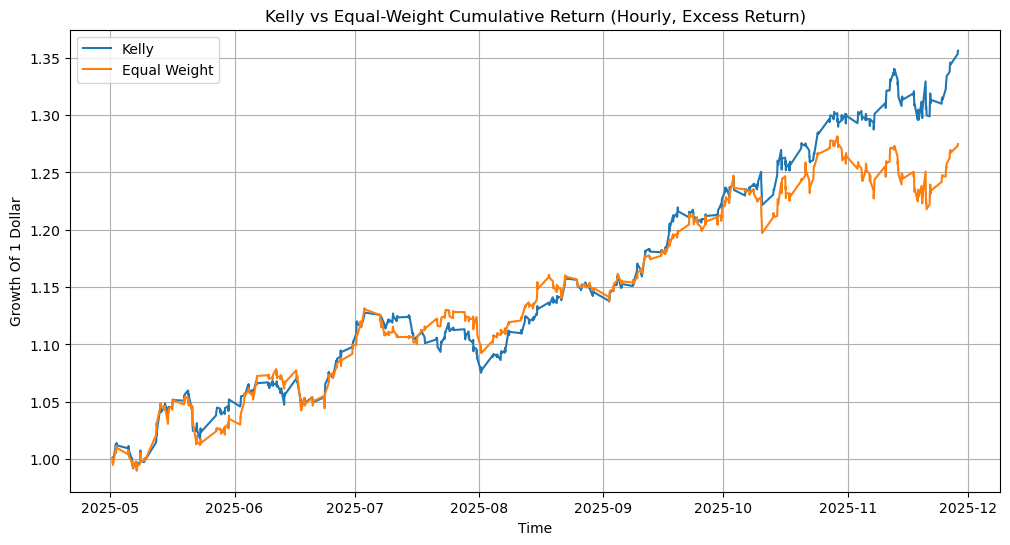

In [43]:
#Use Weights From Time Mforward
valid_slice = slice(M, T)

#Kelly Portfolio
w_R_kelly = weight_kelly[valid_slice,:]*R[valid_slice,:]
port_ret_kelly = np.nansum(w_R_kelly, axis=1)
kelly_cumulative = np.cumprod(1+port_ret_kelly)

#Equal Weight Portfolio
w_R_ew = weight_ew[valid_slice,:]*R[valid_slice,:]
port_ret_ew = np.nansum(w_R_ew, axis=1)
ew_cumulative = np.cumprod(1+port_ret_ew)

#Plot Comparison
time_index = ExcessReturn_df.index[valid_slice]

plt.figure(figsize=(12,6))
plt.plot(time_index, kelly_cumulative, label="Kelly")
plt.plot(time_index, ew_cumulative, label="Equal Weight")
plt.title("Kelly vs Equal-Weight Cumulative Return (Hourly, Excess Return)")
plt.ylabel("Growth Of 1 Dollar")
plt.xlabel("Time")
plt.legend()
plt.grid()
plt.show()

In [44]:
print(last_kelly.sum(), last_kelly.min(), last_kelly.max())

1.0000000000000002 0.0 0.21000000000000002


In this project, I used a rolling-window version of the Kelly Criterion to allocate capital across my portfolio. I collected one year of hourly price data for all assets and converted it into hourly excess returns by subtracting the hourly risk-free rate. To fit the ACE framework used in class, I applied a 24-hour sliding window: for each window, I estimated the expected returns (μ) and the covariance matrix (Σ), and computed a Kelly-style weight vector using the mean-variance approximation f ∝ Σ⁻¹ μ.


Because the pure Kelly solution can include negative weights, I restricted the strategy to a long-only setting by setting any negative values to zero and then normalizing the remaining weights so they sum to one. This produces a diversified Kelly allocation that still reflects the relative strength of each asset within its most recent window of returns.


The resulting sequence of weight vectors forms a dynamic, hour-by-hour Kelly allocation. I used these weights to construct a time-series of portfolio returns and compared the performance to an equal-weight benchmark, following the ACE methodology outlined in the course slides.